### <div style= 'color: orange'> Import all the required modules

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import torch
import itertools
import random

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from tqdm import trange
from numba import jit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tov_tide
%matplotlib widget

### <div style= 'color: orange'> Global constants and unit conversion factors

In [4]:
msun=147660                 # Solar mass in cm given by the formula G*M_sun/c^2

c=2.9979e10                 # speed of light in cm/s (CGS)
G=6.67408e-8                # gravitational constant in cm^3/gm/s^2 (CGS)

dkm = 1.3234e-06            # conversion of MeV/fm^3 to km^-2
dcgs = 1.78e12              # factor to convert from MeV/fm^3 to gm/cm^3
conv = 8.2601e-40           # dyn/cm^2 to km^-2
cgs1=1.7827e+12             # MeV/fm3 to gms/cm3
cgs2=1.6022e+33             # MeV/fm3 to dyne/cm2

### <div style= 'color: orange'>4 Piecewise-polytrope low-density (crust) parameters

In [5]:
# Low density Polytropic exponents
GammaL_1 = 1.35692
GammaL_2 = 0.62223
GammaL_3 = 1.28733
GammaL_4 = 1.58425

# Low density Polytropic constants
KL_1 = 3.99874e-8 # * pow(Msun/Length**3, GammaL_1-1)
KL_2 = 5.32697e+1 # * pow(Msun/Length**3, GammaL_2-1)
KL_3 = 1.06186e-6 # * pow(Msun/Length**3, GammaL_3-1)
KL_4 = 6.80110e-9 # * pow(Msun/Length**3, GammaL_4-1)
# notice a missing c^2 in Ki values in Table II of Read et al. 2009

# Densities at the boundaries of the low density piecewise polytropes
rhoL_1 = 2.62789e12
rhoL_2 = 3.78358e11
rhoL_3 = 2.44034e7
rhoL_4 = 0.0

# Pressures at the boundaries of the low density piecewise polytropes
pL_1 = KL_1*rhoL_1**GammaL_1
pL_2 = KL_2*rhoL_2**GammaL_2
pL_3 = KL_3*rhoL_3**GammaL_3
pL_4 = 0.0

# The exact numbers are taken from a particular crust model/table.

### <div style= 'color: orange'> Low density Energy density, α, and Break densities

In [6]:
# Compute the offsets specific internal energy (epsL_i) and alphaL_i at the 
# boundaries
# The general form used: ε(ρ)=(1+α)ρ+K/(Γ−1)ρ^Γ. 
# Solving for alpha ensures matching across boundaries.
# Energy density needs an additive offset to enforce continuity.

epsL_4 = 0.0
alphaL_4 = 0.0
epsL_3 = (1+alphaL_4)*rhoL_3 + KL_4/(GammaL_4 - 1.)*pow(rhoL_3, GammaL_4)
alphaL_3 = epsL_3/rhoL_3 - 1.0 - KL_3/(GammaL_3 - 1.)*pow(rhoL_3, GammaL_3 -1.0)
epsL_2 = (1+alphaL_3)*rhoL_2 + KL_3/(GammaL_3 - 1.)*pow(rhoL_2, GammaL_3)
alphaL_2 = epsL_2/rhoL_2 - 1.0 - KL_2/(GammaL_2 - 1.)*pow(rhoL_2, GammaL_2 -1.0)
epsL_1 = (1+alphaL_2)*rhoL_1 + KL_2/(GammaL_2 - 1.)*pow(rhoL_1, GammaL_2)
alphaL_1 = epsL_1/rhoL_1 - 1.0 - KL_1/(GammaL_1 - 1.)*pow(rhoL_1, GammaL_1 -1.0)

# Density thresholds for high-density polytropes
rho1 = pow(10,14.7) # Break Density 1
rho2 = pow(10,15.0) # Break Density 2

# GR conversion prefactors to go from cgs pressure/energy-density units into 
# geometric units (where G=c=1)
t_p=G/c**4
t_rho=G/c**2

### <div style= 'color: orange'> Forward EOS: ρ↦(p,ε)
To calculate pressure and energy density for polytropes based on the central density region of intrest

In [7]:
def p_eps_of_rho(rho,logp,Gamma1,Gamma2,Gamma3):
    p1 = pow(10.0,logp)/c**2
    K1 = p1/pow(rho1,Gamma1)
    K2 = K1 * pow( rho1, Gamma1-Gamma2)
    K3 = K2 * pow( rho2, Gamma2-Gamma3)
    rho0 = pow(KL_1/K1,1.0/(Gamma1-GammaL_1)) 
    eps0 = (1.0+alphaL_1)*rho0 + KL_1/(GammaL_1-1.0)*pow(rho0,GammaL_1)
    alpha1 = eps0/rho0 - 1.0 - K1/(Gamma1 - 1.0)*pow(rho0, Gamma1 -1.0)
    eps1 = (1.0+alpha1)*rho1 + K1/(Gamma1 - 1.0)*pow(rho1, Gamma1)
    alpha2 = eps1/rho1 - 1.0 - K2/(Gamma2 - 1.0)*pow(rho1, Gamma2 -1.0)
    eps2 = (1.0+alpha2)*rho2 + K2/(Gamma2 - 1.0)*pow(rho2, Gamma2)
    alpha3 = eps2/rho2 - 1.0 - K3/(Gamma3 - 1.0)*pow(rho2, Gamma3 -1.0)
    if rho<rhoL_3:
        p = KL_4*pow(rho,GammaL_4)
        eps = (1.0+alphaL_4)*rho + KL_4/(GammaL_4-1.0)*pow(rho,GammaL_4)
    elif rhoL_3<= rho <rhoL_2:
        p = KL_3*pow(rho,GammaL_3)
        eps = (1.0+alphaL_3)*rho + KL_3/(GammaL_3-1.0)*pow(rho,GammaL_3)
    elif rhoL_2<= rho <rhoL_1:
        p = KL_2*pow(rho,GammaL_2)
        eps = (1.0+alphaL_2)*rho + KL_2/(GammaL_2-1.0)*pow(rho,GammaL_2)
    elif rhoL_1<= rho <rho0:
        p = KL_1*pow(rho,GammaL_1)
        eps = (1.0+alphaL_1)*rho + KL_1/(GammaL_1-1.0)*pow(rho,GammaL_1)
    elif rho0<= rho <rho1:
        p = K1*pow(rho,Gamma1)
        eps = (1.0+alpha1)*rho + K1/(Gamma1-1.0)*pow(rho,Gamma1)
    elif rho1<= rho <rho2:
        p = K2*pow(rho,Gamma2)
        eps = (1.0+alpha2)*rho + K2/(Gamma2-1.0)*pow(rho,Gamma2)
    else:
        p = K3*pow(rho,Gamma3)
        eps = (1.0+alpha3)*rho + K3/(Gamma3-1.0)*pow(rho,Gamma3)
    return p*c**2, eps*c**2

### <div style= 'color: orange'> Inverse EOS: p↦ε
To calculate Energy denisty for every central pressure value of intrest 
while solving a polytrope

In [8]:
@jit(nopython=True)
def eps(p,logp,Gamma1,Gamma2,Gamma3):
    p1 = pow(10.0,logp)/c**2
    p*=1/c**2
    K1 = p1/pow(rho1,Gamma1)
    K2 = K1 * pow( rho1, Gamma1-Gamma2)
    K3 = K2 * pow( rho2, Gamma2-Gamma3)
    rho0 = pow(KL_1/K1,1.0/(Gamma1-GammaL_1))
    eps0 = (1.0+alphaL_1)*rho0 + KL_1/(GammaL_1-1.0)*pow(rho0,GammaL_1)
    alpha1 = eps0/rho0 - 1.0 - K1/(Gamma1 - 1.0)*pow(rho0, Gamma1 -1.0)
    eps1 = (1.0+alpha1)*rho1 + K1/(Gamma1 - 1.0)*pow(rho1, Gamma1)
    alpha2 = eps1/rho1 - 1.0 - K2/(Gamma2 - 1.0)*pow(rho1, Gamma2 -1.0)
    eps2 = (1.0+alpha2)*rho2 + K2/(Gamma2 - 1.0)*pow(rho2, Gamma2)
    alpha3 = eps2/rho2 - 1.0 - K3/(Gamma3 - 1.0)*pow(rho2, Gamma3 -1.0)
    p0 = K1*pow(rho0,Gamma1)
    p2 = K3*pow(rho2,Gamma3)
    if  p<pL_3:
        rho = pow(p/KL_4,1/GammaL_4)
        eps = (1.0+alphaL_4)*rho + KL_4/(GammaL_4-1.0)*pow(rho,GammaL_4)
    elif pL_3<= p <pL_2:
        rho = pow(p/KL_3,1/GammaL_3)
        eps = (1.0+alphaL_3)*rho + KL_3/(GammaL_3-1.0)*pow(rho,GammaL_3)
    elif pL_2<= p <pL_1:
        rho = pow(p/KL_2,1/GammaL_2)
        eps = (1.0+alphaL_2)*rho + KL_2/(GammaL_2-1.0)*pow(rho,GammaL_2)
    elif  pL_1<p <p0:
        rho = pow(p/KL_1,1/GammaL_1)
        eps = (1.0+alphaL_1)*rho + KL_1/(GammaL_1-1.0)*pow(rho,GammaL_1)
    elif p0<= p <p1:
        rho = pow(p/K1,1/Gamma1)
        eps = (1.0+alpha1)*rho + K1/(Gamma1-1.0)*pow(rho,Gamma1)
    elif p1<= p <p2:
        rho = pow(p/K2,1/Gamma2)
        eps = (1.0+alpha2)*rho + K2/(Gamma2-1.0)*pow(rho,Gamma2)
    else:
        rho = pow(p/K3,1/Gamma3)
        eps = (1.0+alpha3)*rho + K3/(Gamma3-1.0)*pow(rho,Gamma3)
    return eps*c**2

### <div style= 'color: orange'> The TOV Integrator

In [9]:
def TOV(logrho_c, theta, compute_tidal=True):
    logp, Gamma1, Gamma2, Gamma3 = theta
    dr = 100.0              # radial step in meters

    rho_c = 10**logrho_c    # Central density in cgs units (g/cm^3)
    r = 0.1                 # Initial Radius (Non-zero to avoid singularity)
    m = 0.0                 # Initial Mass

    p, e = p_eps_of_rho(rho_c, logp, Gamma1, Gamma2, Gamma3)
    p *= t_p    # pressure in geometric units
    e *= t_p    # energy density in geometric units

    # Store profiles to calculate TD
    p_prof = []
    e_prof = []
    r_prof = []
    m_prof = []

    while p > 0:    # As long as pressure is greater than 0
        p_prof.append(p)
        e_prof.append(e)
        r_prof.append(r)
        m_prof.append(m)

        dp = -(e + p) * (m + 4*np.pi*r**3*p) / (r*(r - 2*m))
        p += dp * dr    # Update pressure at each radial step
        if p <= 0:      # Break when pressure reaches 0
            break

        m += 4*np.pi*r**2 * e * dr  # Update mass
        r += dr                     # Update radius
        e = eps(p/t_p, logp, Gamma1, Gamma2, Gamma3) * t_p # Update energy density

    # --- Final mass and radius ---
    M = m / msun
    R = r / 1e5

    if not compute_tidal:
        return M, R

    # prepare inputs for Fortran tov_tide.tov_tide
    p_prof = np.array(p_prof, dtype=np.float64)
    e_prof = np.array(e_prof, dtype=np.float64)
    # Fortran expects central pressure at index N
    p_prof = p_prof[::-1]
    e_prof = e_prof[::-1]
    pc = p_prof[-1]
    # N = len(p_prof)

    # --- Calculate tidal deformability ---
    M_tide, R_tide, L = tov_tide.tov_tide(
        e_prof,
        p_prof,
        pc
    )
    return M, R, L # Returns true TD (not log TD)

### <div style= 'color: Yellow'>Model Definition

In [10]:
# ==========================================================
# Single Residual Network Block
# ==========================================================
class ResNetBlock(nn.Module):
    def __init__(self, hidden_dim, auxiliary_dim=1):
        super().__init__()
        # We accept the hidden state + the auxiliary Central Pressure injection
        self.fc = nn.Linear(hidden_dim + auxiliary_dim, hidden_dim)
        self.act = nn.GELU() # Gaussian Error Linear Unit
    
    def forward(self, x, cp):
        # Concatenate Central Pressure to the input of the layer
        combined = torch.cat([x, cp], dim=1)
        out = self.act(self.fc(combined))
        return x + out # Residual connection

# ==========================================================
# Set up the Residual Network flow
# ==========================================================
class PhysicsEmulator(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=512): 
        super().__init__()
        # Separate EOS inputs from Central Pressure
        # input_dim is 5: (4 EOS params + 1 Central Pressure)
        self.eos_dim = input_dim - 1 
        
        # 1. Initial encoding of EOS parameters only: 
        self.input_layer = nn.Linear(self.eos_dim, hidden_dim)
        
        # 2. Deep Residual Layers with Central Pressure Injection
        self.block1 = ResNetBlock(hidden_dim, auxiliary_dim=1)
        self.block2 = ResNetBlock(hidden_dim, auxiliary_dim=1)
        self.block3 = ResNetBlock(hidden_dim, auxiliary_dim=1)
        self.block4 = ResNetBlock(hidden_dim, auxiliary_dim=1)

        # 3. Output layers
        self.final_layer = nn.Sequential(
            nn.Linear(hidden_dim + 1, hidden_dim // 2), # Inject Central Pressure one last time
            nn.GELU(),                                      # 513 --> 256
            nn.Linear(hidden_dim // 2, 3)                   # Output: 256 --> 3
        )
        
    def forward(self, x):
        # Split input into EOS params and Central Pressure
        # Central Pressure is the second column
        cp = x[:, 1:2]
        # EOS parameters are the remaining columns
        eos_params = torch.cat([x[:, 0:1], x[:, 2:]], dim=1)

        # 1. Encode EOS
        x_hidden = self.input_layer(eos_params)           # Input: 5 --> 512

        # 2. Central Pressure-Injected Residual Flow: Pass through blocks, injecting Central Pressure at each step
        x_hidden = self.block1(x_hidden, cp)              # 512 + 1 --> 512
        x_hidden = self.block2(x_hidden, cp)              # 512 + 1 --> 512
        x_hidden = self.block3(x_hidden, cp)              # 512 + 1 --> 512
        x_hidden = self.block4(x_hidden, cp)              # 512 + 1 --> 512
        
        # 3. Final Prediction
        # Concatenate Central Pressure one last time for the read-out
        combined_final = torch.cat([x_hidden, cp], dim=1) # 512 + 1 = 513
        return self.final_layer(combined_final)             

### <div style= 'color: Yellow'> Testing the Model for a grid of Unseen CD + CP + EOS parameters

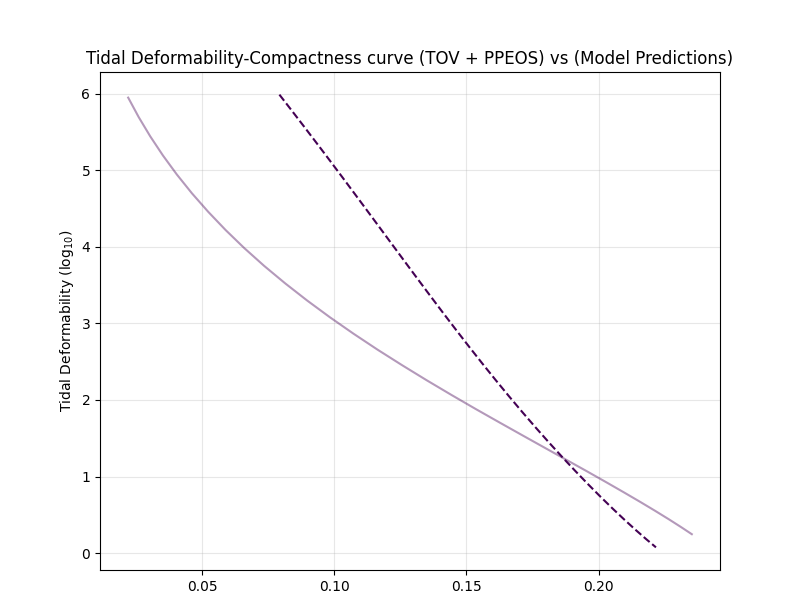

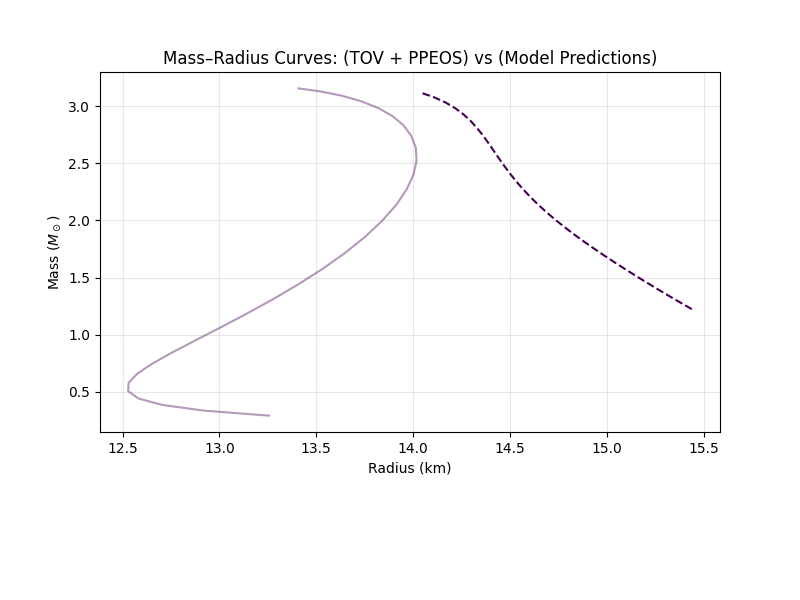

In [15]:
# ==========================================================
# 1. Configuration and constants
# ==========================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_SAMPLES = 200

RADIUS_SCALE = 25.0
MASS_SCALE = 3.5

# for local outputs:
# save_dir_outputs = f"Outputs/{NUM_SAMPLES}files"
# for outputs copied over from cluster:
save_dir_outputs = f"/home/kay/Master-Thesis/ResNet_PP(EOS+CP)_MRTD_Emulator/Cluster_Output/{NUM_SAMPLES}files"
save_dir_testing = f"/home/kay/Master-Thesis/ResNet_PP(EOS+CP)_MRTD_Emulator/Testing/{NUM_SAMPLES}files"

MODEL_NO = 2    # For saving plots <--------------------------------------------

# ==========================================================
# 2. Set ranges for the parameters of the EOS for the curves to be tested
# ==========================================================
Gamma1_values = [1.6, 2.5, 3.5, 4.5, 4.9]   # Should be within training range.
Gamma2_values = [1.6, 2.5, 3.5, 4.5, 4.9]   # Values outside the training range
Gamma3_values = [1.6, 2.5, 3.5, 4.5, 4.9]   # would be extrapolation

logp_values = [33.6, 34.0, 34.4, 34.8]

logrho_c_array = np.linspace(14.5, 15.4, 60) # sample different central densities

# Randomly select combinations of (Γ1,Γ2,Γ3,logp)
param_combinations = list(itertools.product(Gamma1_values, Gamma2_values, Gamma3_values, logp_values))
sampled_combinations = random.sample(param_combinations, 1)  # 5 random combos

# ==========================================================
# 3. Prepare models and Scalars
# ==========================================================
# Load model and call to device
model = PhysicsEmulator().to(DEVICE)
model.load_state_dict(torch.load(os.path.join(save_dir_outputs, "Best_EOS_Model.pth"), map_location=DEVICE))
model.eval()    # Set model in evaluation mode

# Load the means and stds for normalization from training
X_mean = torch.load(os.path.join(save_dir_outputs, "X_eos_mean.pt")).to(DEVICE)
X_std = torch.load(os.path.join(save_dir_outputs, "X_eos_std.pt")).to(DEVICE)

# Initialize lists to store results
predicted_mass = []
predicted_radius = []
predicted_td = []
original_mass = []
original_radius = []
original_td = []

# ==========================================================
# 4. Evaluation and plot loop
# ==========================================================
fig1, ax1 = plt.subplots(figsize=(8, 6))
fig2, ax2 = plt.subplots(figsize=(8, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(sampled_combinations)))

for color, (Gamma1, Gamma2, Gamma3, logp) in zip(colors, sampled_combinations):
    predicted_mass_single = []
    predicted_radius_single = []
    predicted_td_single = []

    original_mass_single = []
    original_radius_single = []
    original_td_single = []

    for logrho_c in logrho_c_array:
        # Normalize all input parameters using Z-Score
        input_eos_params = torch.tensor([[logrho_c, logp, Gamma1, Gamma2, Gamma3]], dtype=torch.float32).to(DEVICE)
        input_norm = ((input_eos_params - X_mean) / X_std).to(DEVICE)

        # Predict M, R and TD with trained model
        with torch.no_grad():
            prediction = model(input_norm)

        # Bring predictions to cpu
        pred = prediction.cpu().numpy()

        # Denormalize outputs
        M_pred_denorm = float(pred[0, 0] * MASS_SCALE)
        R_pred_denorm = float(pred[0, 1] * RADIUS_SCALE)
        TD_pred_log = float(pred[0, 2])  # Keep log scaling

        # Remove unphysical predictions
        if not (
            np.isfinite(M_pred_denorm) and
            np.isfinite(R_pred_denorm) and
            np.isfinite(TD_pred_log) and
            0.15 < M_pred_denorm < 3.5 and
            6.0 < R_pred_denorm < 25.0 and
            0 < TD_pred_log < 10.0

        ):
            continue

        # Calculate Original TOV solutions using the TOV solver
        M_orig, R_orig, TD_orig = TOV(logrho_c, [logp, Gamma1, Gamma2, Gamma3])

        # Remove unphysical values
        if not (
            np.isfinite(M_orig) and
            np.isfinite(R_orig) and
            np.isfinite(TD_orig) and
            0.15 < M_orig < 3.5 and
            6.0 < R_orig < 25.0 and
            0 < np.log10(TD_orig) < 10.0
        ):
            continue

        # Store single curve results
        predicted_mass_single.append(M_pred_denorm)
        predicted_radius_single.append(R_pred_denorm)
        original_mass_single.append(M_orig)
        original_radius_single.append(R_orig)
        predicted_td_single.append(TD_pred_log)
        original_td_single.append(np.log10(TD_orig))

    # Append to overall lists
    predicted_mass.append(predicted_mass_single)    
    predicted_radius.append(predicted_radius_single)
    original_mass.append(original_mass_single)
    original_radius.append(original_radius_single)
    original_td.append(original_td_single)
    predicted_td.append(predicted_td_single)

    # Convert lists to numpy arrays
    orig_M = np.array(original_mass_single)
    orig_R = np.array(original_radius_single)
    pred_M = np.array(predicted_mass_single)
    pred_R = np.array(predicted_radius_single)

    # Plot label
    label = rf"$\log\rho_c= {logrho_c:.2f}$, Γ=({Gamma1},{Gamma2},{Gamma3}), logp={logp:.2f}"

    # Plot M-R curves
    ax1.plot(original_radius_single, original_mass_single, '-', color=color, alpha=0.4, label=f"TOV {label}")
    ax1.plot(predicted_radius_single, predicted_mass_single, '--', color=color, label=f"Pred {label}")
    
    # Plot TD-Compactness Curves
    ax2.plot(orig_M / orig_R, original_td_single, "-", color=color, alpha=0.4, label=f"TOV + PPEOS {label}")
    ax2.plot(pred_M / pred_R, predicted_td_single, "--", color=color, label=f"Model Prediction {label}")

    # Plot Formatting
    ax1.set_title("Mass–Radius Curves: (TOV + PPEOS) vs (Model Predictions)")
    ax1.set_xlabel("Radius (km)")
    ax1.set_ylabel(r"Mass ($M_\odot$)")
    # ax1.set_xlim(6, 20)
    # ax1.set_ylim(0, 3.5)
    ax1.grid(alpha=0.3)

    ax2.set_title("Tidal Deformability-Compactness curve (TOV + PPEOS) vs (Model Predictions)")
    ax2.set_xlabel(r"Compactness ($M/R$)")
    ax2.set_ylabel("Tidal Deformability (log$_{10}$)")
    ax2.grid(alpha=0.3)

# M-R Plot Legend
fig1.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    fontsize="small",
    ncol=2
)
fig1.subplots_adjust(bottom=0.28)
# TD-Compactness Plot Legend
fig2.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    fontsize="small",
    ncol=2
)
fig2.subplots_adjust(bottom=0.05)

# Save both plots
os.makedirs(save_dir_testing, exist_ok=True)
fig1.savefig(os.path.join(save_dir_testing, f"MR_unseen_{MODEL_NO}.svg"), bbox_inches="tight")
fig2.savefig(os.path.join(save_dir_testing, f"TD_compactness_unseen_{MODEL_NO}.svg"), bbox_inches="tight")

plt.show()

### <div style= 'color: yellow'> Model Metrics

In [16]:
# All original values
orig_mass_all = np.concatenate(original_mass)
orig_radius_all = np.concatenate(original_radius)
orig_td_all = np.concatenate(original_td)

# All predicted values
pred_mass_all = np.concatenate(predicted_mass)
pred_radius_all = np.concatenate(predicted_radius)
pred_td_all = np.concatenate(predicted_td)

# Mass Metrics
mae_mass = mean_absolute_error(orig_mass_all, pred_mass_all)
rmse_mass = np.sqrt(mean_squared_error(orig_mass_all, pred_mass_all))
r2_mass = r2_score(orig_mass_all, pred_mass_all)

# Radius Metrics
mae_radius = mean_absolute_error(orig_radius_all, pred_radius_all)
rmse_radius = np.sqrt(mean_squared_error(orig_radius_all, pred_radius_all))
r2_radius = r2_score(orig_radius_all, pred_radius_all)

# TD Metrics
mae_td = mean_absolute_error(orig_td_all, pred_td_all)
rmse_td = np.sqrt(mean_squared_error(orig_td_all, pred_td_all))
r2_td = r2_score(orig_td_all, pred_td_all)

# Normalized MSE of the model for all three parameters combined
norm_rmse = np.mean([
    rmse_radius / np.mean(orig_radius_all),
    rmse_mass / np.mean(orig_mass_all),
    rmse_td / np.mean(orig_td_all)
])

print(f"Radius:  MAE={mae_radius:.4f}, RMSE={rmse_radius:.4f}, R²={r2_radius:.4f}")
print(f"Mass:  RMSE={rmse_mass:.4f}, R²={r2_mass:.4f}")
print(f"TD:  MAE={mae_td:.4f}, RMSE={rmse_td:.4f}, R²={r2_td:.4f}")
print(f"Combined normalized RMSE = {norm_rmse:.4f}")

Radius:  MAE=1.2907, RMSE=1.5517, R²=-7.8246
Mass:  RMSE=0.6280, R²=0.5930
TD:  MAE=0.1628, RMSE=0.1829, R²=0.9890
Combined normalized RMSE = 0.1822


In [17]:
# ==========================================================
# Save Metrics to a Text file
# ==========================================================
output_file = os.path.join(save_dir_testing, f"Model_metrics_{MODEL_NO}.txt")

with open(output_file, "w") as f:
    f.write("Mass, Radius and TD prediction metrics\n")
    f.write("======================================\n")

    f.write("Mass Prediction Metrics:\n")
    f.write(f"MAE   : {mae_mass:.6f}\n")
    f.write(f"RMSE  : {rmse_mass:.6f}\n")
    f.write(f"R^2   : {r2_mass:.6f}\n")
    f.write("\n")

    f.write("Radius Prediction Metrics:\n")
    f.write(f"MAE   : {mae_radius:.6f}\ n")
    f.write(f"RMSE  : {rmse_radius:.6f}\n")
    f.write(f"R^2   : {r2_radius:.6f}\n")
    f.write("\n")

    f.write("Tidal Deformability Prediction Metrics:\n")
    f.write(f"MAE   : {mae_td:.6f}\n")
    f.write(f"RMSE  : {rmse_td:.6f}\n")
    f.write(f"R^2   : {r2_td:.6f}\n")
    f.write("\n")

    f.write(f"Norm RMSE : {norm_rmse:.6f}\n")
    
print(f"Metrics saved to {output_file}")


Metrics saved to /home/kay/Master-Thesis/ResNet_PP(EOS+CP)_MRTD_Emulator/Testing/200files/Model_metrics_2.txt
